# 07 — Sentiment exploration

**Pivot context:** market prediction analyse leverde modesteklikker signaal op (AUC 0.55,
event-driven). We bekijken nu Trump's sentiment dynamics als nieuw onderzoeksonderwerp.

**Plan:**
1. Load raw Kaggle CSV met pre-computed sentiment labels.
2. Verken de sentiment-distributies (label + continuous score).
3. Sentiment over tijd (2022 → 2026): trend, piek-momenten.
4. Topic × sentiment crosstab.
5. Engagement × sentiment relaties.
6. Voorbeelden van extreme positive/negative posts.
7. Toxicity scores.
8. Definieer scope voor next notebook (text classifier).

**Goal:** binnen één notebook genoeg materiaal verzamelen om de richting van het
sentiment-thesis te onderbouwen.


In [19]:

# Standaard events voor alle tijdlijn-plots
_PLOT_EVENTS = [
    ("2025-01-20", "Inauguratie Trump",  "#3498db"),
    ("2025-04-02", "Liberation Day",     "#e74c3c"),
    ("2025-04-09", "90d pauze",          "#f39c12"),
    ("2025-05-12", "Genève truce",       "#27ae60"),
    ("2026-02-28", "Iran conflict start","#c0392b"),
    ("2026-04-11", "Hormuz blokkade",    "#e67e22"),
]

def _add_events(ax, y_frac=0.97, fontsize=7.5):
    """Voeg verticale event-lijnen toe aan ax (alleen als datum binnen x-limiet valt)."""
    xmin, xmax = ax.get_xlim()
    for d_str, label, color in _PLOT_EVENTS:
        d = pd.Timestamp(d_str, tz="UTC")
        d_num = mdates.date2num(d.to_pydatetime())
        if xmin <= d_num <= xmax:
            ax.axvline(d, color=color, linewidth=1.0, linestyle="--", alpha=0.75, zorder=3)
            ylim = ax.get_ylim()
            ax.text(d, ylim[0] + (ylim[1]-ylim[0])*y_frac, " "+label,
                    rotation=90, va="top", ha="left", fontsize=fontsize,
                    color=color, alpha=0.85, zorder=4)


In [20]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas={pd.__version__}, numpy={np.__version__}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
pandas=3.0.2, numpy=2.4.4


## 1. Load raw Kaggle data

De `posts.parquet` bevat alleen canonical kolommen. We laden hier de raw CSV
om de pre-computed sentiment-features mee te krijgen.


In [21]:
raw = pd.read_csv("../data/raw/trump_truth_archive.csv", low_memory=False)
raw["created_at"] = pd.to_datetime(raw["created_at"], utc=True, format="ISO8601")

# Filter media-only posts (zonder text) — geen sentiment voor te bepalen
raw = raw.dropna(subset=["text", "sentiment_score", "sentiment_label"]).reset_index(drop=True)

print(f"Shape: {raw.shape}")
print(f"Date range: {raw['created_at'].min().date()} → {raw['created_at'].max().date()}")
print(f"\nSentiment-related columns:")
sentiment_cols = ["sentiment_score", "sentiment_label", "emotion", "toxicity_score",
                  "topic", "rhetorical_device", "target_entity", "sentiment_toward_target",
                  "is_policy_related"]
print(raw[sentiment_cols].dtypes)

Shape: (26819, 40)
Date range: 2022-02-14 → 2026-04-23

Sentiment-related columns:
sentiment_score            float64
sentiment_label                str
emotion                        str
toxicity_score             float64
topic                          str
rhetorical_device              str
target_entity                  str
sentiment_toward_target        str
is_policy_related           object
dtype: object


## 2. Sentiment label distributie

Eerste sanity check: hoe verdeeld is het label?


sentiment_label
neutral     10827
positive     9813
negative     6179
Name: count, dtype: int64

sentiment_label
neutral     40.4%
positive    36.6%
negative    23.0%
Name: count, dtype: str


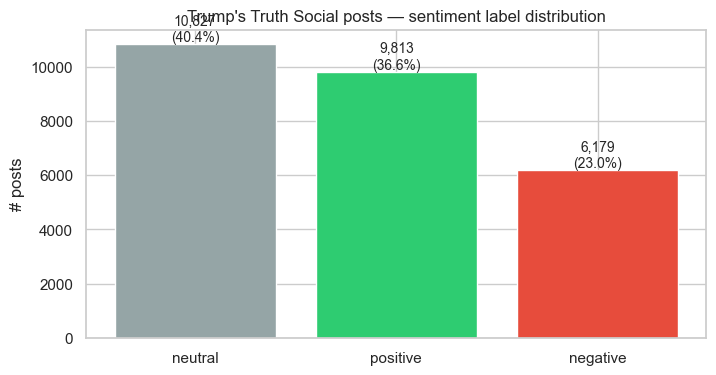

In [22]:
label_counts = raw["sentiment_label"].value_counts()
print(label_counts)
print()
print((label_counts / len(raw) * 100).round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(8, 4))
colors = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#95a5a6"}
ax.bar(label_counts.index, label_counts.values,
       color=[colors.get(l, "#3498db") for l in label_counts.index],
       edgecolor="white")
for i, v in enumerate(label_counts.values):
    ax.text(i, v, f"{v:,}\n({v/len(raw)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_title("Trump's Truth Social posts — sentiment label distribution")
ax.set_ylabel("# posts")
plt.show()

## 3. Sentiment score (continuous) distributie


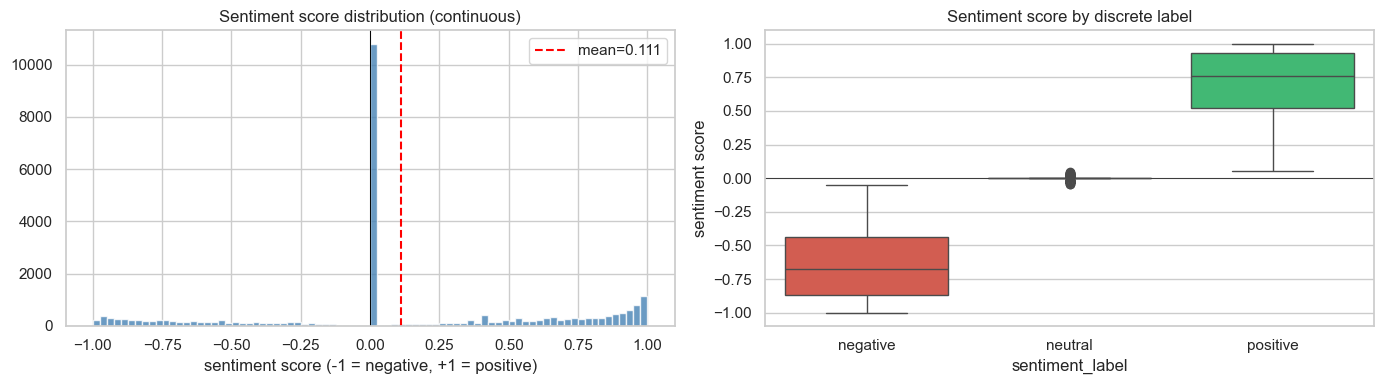

                   count   mean    std    min    25%    50%    75%    max
sentiment_label                                                          
negative          6179.0 -0.637  0.255 -0.998 -0.864 -0.678 -0.440 -0.052
neutral          10827.0  0.000  0.002 -0.040  0.000  0.000  0.000  0.048
positive          9813.0  0.703  0.248  0.051  0.522  0.757  0.927  0.998


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(raw["sentiment_score"], bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="black", linewidth=0.7)
axes[0].axvline(raw["sentiment_score"].mean(), color="red", linestyle="--",
                label=f"mean={raw['sentiment_score'].mean():.3f}")
axes[0].set_title("Sentiment score distribution (continuous)")
axes[0].set_xlabel("sentiment score (-1 = negative, +1 = positive)")
axes[0].legend()

# Box plot per label
sns.boxplot(data=raw, x="sentiment_label", y="sentiment_score", ax=axes[1],
            order=["negative", "neutral", "positive"],
            palette=["#e74c3c", "#95a5a6", "#2ecc71"])
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Sentiment score by discrete label")
axes[1].set_ylabel("sentiment score")
plt.tight_layout()
plt.show()

print(raw.groupby("sentiment_label")["sentiment_score"].describe().round(3))

## 4. Sentiment over tijd

Hoe evolueert Trump's gemiddelde sentiment door de jaren? Pieken te zien rond
verkiezingen, rechtszaken, inauguratie?


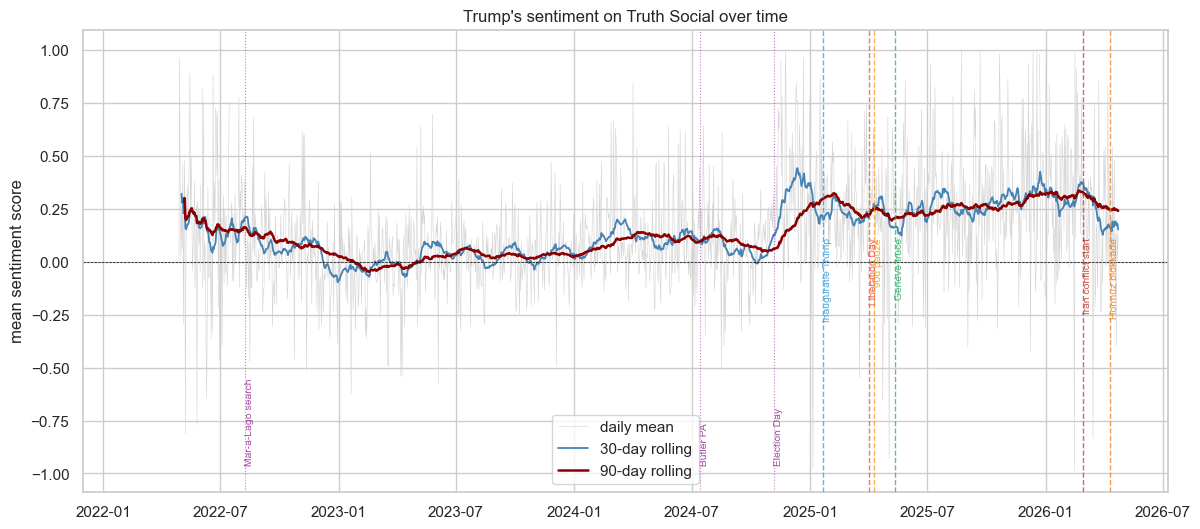

In [24]:
# 30-day rolling mean
daily_sent = raw.set_index("created_at")["sentiment_score"].resample("D").mean()
rolling_30d = daily_sent.rolling(30, min_periods=5).mean()
rolling_90d = daily_sent.rolling(90, min_periods=10).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_sent.index, daily_sent.values, color="lightgray", linewidth=0.4, label="daily mean")
ax.plot(rolling_30d.index, rolling_30d.values, color="steelblue", linewidth=1.3, label="30-day rolling")
ax.plot(rolling_90d.index, rolling_90d.values, color="darkred", linewidth=1.8, label="90-day rolling")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

# Persoonlijke events (politiek)
personal_events = [
    ("2022-08-08", "Mar-a-Lago search", "purple"),
    ("2024-07-13", "Butler PA",         "purple"),
    ("2024-11-05", "Election Day",      "purple"),
]
for d_str, label, color in personal_events:
    d = pd.Timestamp(d_str, tz="UTC")
    ax.axvline(d, color=color, linewidth=0.8, alpha=0.5, linestyle=":")
    ax.text(d, ax.get_ylim()[0] + (ax.get_ylim()[1]-ax.get_ylim()[0])*0.05, " "+label,
            rotation=90, va="bottom", ha="left", fontsize=7.5, color=color, alpha=0.7)

# Markt-relevante events (uit ons onderzoek)
_add_events(ax, y_frac=0.55)

ax.set_title("Trump\'s sentiment on Truth Social over time")
ax.set_ylabel("mean sentiment score")
ax.legend()
plt.savefig("../reports/figures/07_sentiment_over_tijd.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Topic verdeling

Hoe vaak komen verschillende topics voor?


topic
Elections              6818
Other                  5845
Legal                  5199
Media                  2099
Economy                1911
Foreign Policy         1653
Personal               1420
Immigration            1018
Military                334
Religion                247
Legal|Elections          29
Policy Statement         18
Policy                   13
Healthcare               13
Economy|Immigration      12
Name: count, dtype: int64


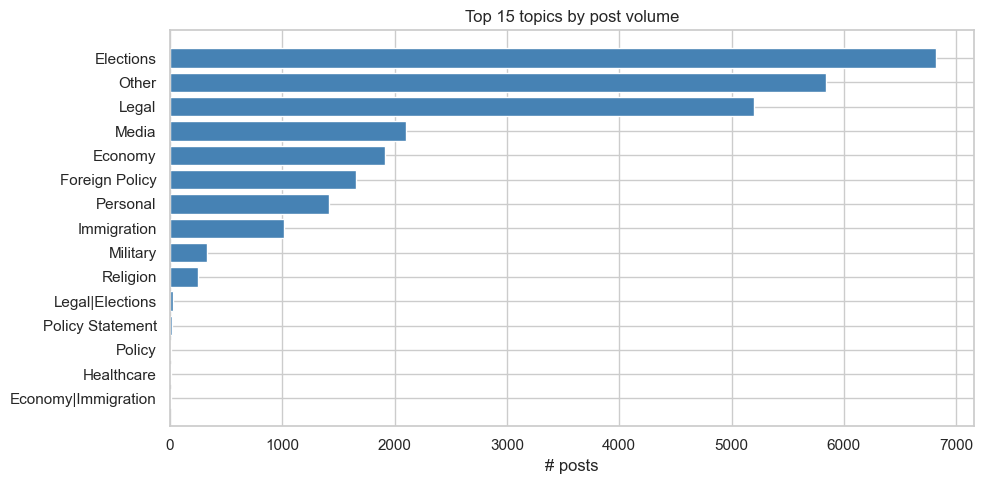

In [25]:
topic_counts = raw["topic"].value_counts()
print(topic_counts.head(15))

fig, ax = plt.subplots(figsize=(10, 5))
top_topics = topic_counts.head(15)
ax.barh(top_topics.index[::-1], top_topics.values[::-1], color="steelblue", edgecolor="white")
ax.set_title("Top 15 topics by post volume")
ax.set_xlabel("# posts")
plt.tight_layout()
plt.show()

## 6. Topic × sentiment crosstab

Welke topics krijgen het meest positieve, welke het meest negatieve sentiment?


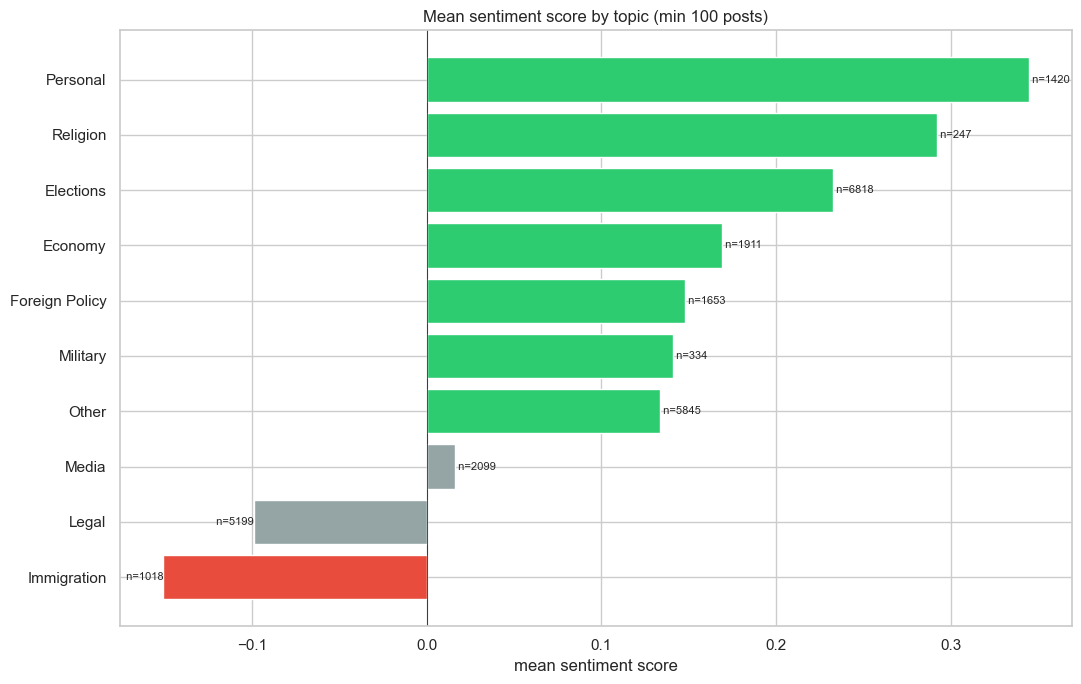

In [26]:
# Top-10 topics, mean sentiment + count
topic_sent = raw.groupby("topic").agg(
    mean_sentiment=("sentiment_score", "mean"),
    n_posts=("sentiment_score", "count"),
).query("n_posts >= 100").sort_values("mean_sentiment")

fig, ax = plt.subplots(figsize=(11, 7))
colors_topic = ["#e74c3c" if s < -0.1 else ("#2ecc71" if s > 0.1 else "#95a5a6")
                for s in topic_sent["mean_sentiment"]]
ax.barh(topic_sent.index, topic_sent["mean_sentiment"], color=colors_topic, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.5)
for i, (idx, row) in enumerate(topic_sent.iterrows()):
    ax.text(row["mean_sentiment"], i,
            f" n={int(row['n_posts'])}", va="center", fontsize=8,
            ha="left" if row["mean_sentiment"] >= 0 else "right")
ax.set_title("Mean sentiment score by topic (min 100 posts)")
ax.set_xlabel("mean sentiment score")
plt.tight_layout()
plt.show()

## 7. Engagement × sentiment

Krijgen negative posts meer engagement dan positive? Belangrijke vraag voor je thesis:
is er een **viral feedback loop** op negativiteit?


                 n_posts  median_likes  median_retruths  median_replies  \
sentiment_label                                                           
negative            6179       14874.0           4041.0           789.0   
neutral            10827        8878.0           2260.0           233.0   
positive            9813       13633.0           3326.0           552.0   

                 mean_likes  mean_retruths  
sentiment_label                             
negative            16525.0         4487.0  
neutral              9360.0         2439.0  
positive            15880.0         3871.0  


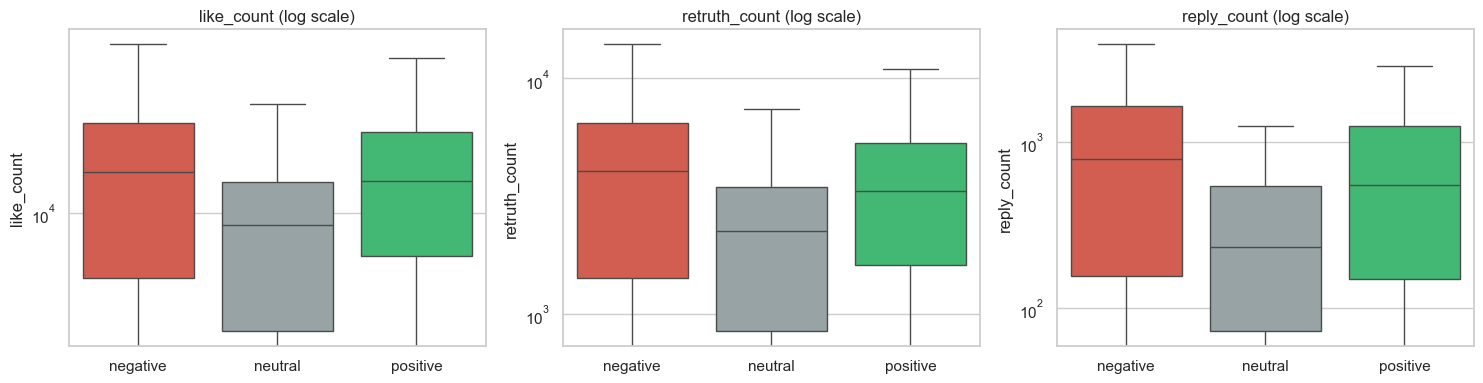

In [27]:
# Aggregeer engagement per sentiment label
engagement_by_sentiment = raw.groupby("sentiment_label").agg(
    n_posts=("like_count", "count"),
    median_likes=("like_count", "median"),
    median_retruths=("retruth_count", "median"),
    median_replies=("reply_count", "median"),
    mean_likes=("like_count", "mean"),
    mean_retruths=("retruth_count", "mean"),
).round(0)
print(engagement_by_sentiment)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
order = ["negative", "neutral", "positive"]
palette = ["#e74c3c", "#95a5a6", "#2ecc71"]

for ax, metric in zip(axes, ["like_count", "retruth_count", "reply_count"]):
    # Log-y because engagement is heavily skewed
    sns.boxplot(data=raw, x="sentiment_label", y=metric, ax=ax,
                order=order, palette=palette, showfliers=False)
    ax.set_yscale("log")
    ax.set_title(f"{metric} (log scale)")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [28]:
# Krijgen negatieve posts meer engagement dan positieve? (bootstrap i.p.v. Mann-Whitney)
from src.evaluation.bootstrap import bootstrap_diff_ci

neg = raw.loc[raw["sentiment_label"] == "negative", "like_count"]
pos = raw.loc[raw["sentiment_label"] == "positive", "like_count"]

# Engagement is heavy-tailed -> bootstrap-CI op het MEDIAAN-verschil (in-cursus resampling).
b = bootstrap_diff_ci(neg, pos, stat=np.median)
print("Krijgen negatieve posts meer engagement (likes) dan positieve?")
print(f"  mediaan negatief: {neg.median():.0f}  |  mediaan positief: {pos.median():.0f}")
print(f"  mediaan-verschil: {b['obs_diff']:+.0f} likes  95%CI=[{b['ci_low']:.0f}, {b['ci_high']:.0f}]")
print(f"  CI sluit 0 uit (negatief > positief): {b['excludes_zero'] and b['ci_low'] > 0}")


Krijgen negatieve posts meer engagement (likes) dan positieve?
  mediaan negatief: 14874  |  mediaan positief: 13633
  mediaan-verschil: +1241 likes  95%CI=[788, 1639]
  CI sluit 0 uit (negatief > positief): True


## 8. Voorbeelden van extreme posts

Welke 5 posts hebben het meest positieve sentiment, en welke 5 het meest negatieve?


In [29]:
print("=== Top-5 MOST POSITIVE posts ===\n")
top_pos = raw.nlargest(5, "sentiment_score")[["created_at", "sentiment_score", "like_count", "text"]]
for _, row in top_pos.iterrows():
    print(f"[{row['created_at'].date()}]  score={row['sentiment_score']:.3f}  likes={row['like_count']:,}")
    print(f"  {row['text'][:200]}")
    print()

print("\n=== Top-5 MOST NEGATIVE posts ===\n")
top_neg = raw.nsmallest(5, "sentiment_score")[["created_at", "sentiment_score", "like_count", "text"]]
for _, row in top_neg.iterrows():
    print(f"[{row['created_at'].date()}]  score={row['sentiment_score']:.3f}  likes={row['like_count']:,}")
    print(f"  {row['text'][:200]}")
    print()

=== Top-5 MOST POSITIVE posts ===

[2025-03-28]  score=0.998  likes=16,882
  Today, President Donald J. Trump and Skadden, Arps, Slate, Meagher & Flom LLP announce the following agreement regarding a series of actions to be taken by Skadden:1. Skadden will provide a total of a

[2025-12-23]  score=0.998  likes=17,699
  THE TRUMP RULE:The Financial News today was great — GDP up 4.2% as opposed to the predicted 2.5% (and this, despite the downward pressure of the recent Democrat Shutdown!) — But in the Modern Market, 

[2026-04-17]  score=0.998  likes=17,750
  Later today, I will be speaking to a BIG CROWD for Turning Point USA in the Great State of Arizona, then flying back to the White House and, therefore, will not be at Mar-a-Lago tonight for a very spe

[2025-10-30]  score=0.998  likes=33,627
  I had a truly great meeting with President Xi of China. There is enormous respect between our two Countries, and that will only be enhanced with what just took place. We agreed on many things

## 9. Toxicity scores

De Kaggle dataset bevat ook `toxicity_score`. Hoe correleert die met sentiment?


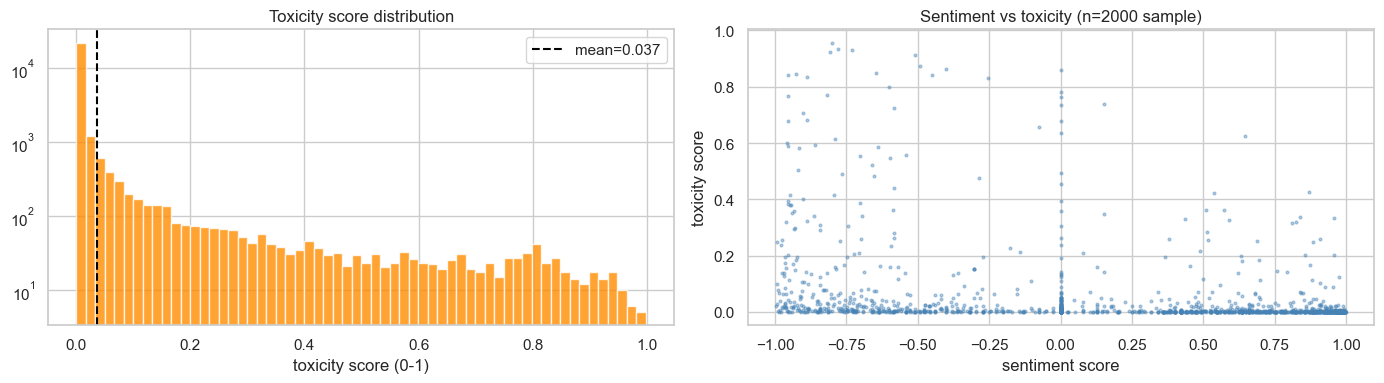

Pearson correlatie sentiment ↔ toxicity: -0.263


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(raw["toxicity_score"], bins=60, color="darkorange", edgecolor="white", alpha=0.8)
axes[0].axvline(raw["toxicity_score"].mean(), color="black", linestyle="--",
                label=f"mean={raw['toxicity_score'].mean():.3f}")
axes[0].set_title("Toxicity score distribution")
axes[0].set_xlabel("toxicity score (0-1)")
axes[0].set_yscale("log")
axes[0].legend()

# Sentiment vs toxicity scatter (samples vanwege grote dataset)
sample = raw.sample(2000, random_state=42)
axes[1].scatter(sample["sentiment_score"], sample["toxicity_score"],
                s=4, alpha=0.4, color="steelblue")
axes[1].set_xlabel("sentiment score")
axes[1].set_ylabel("toxicity score")
axes[1].set_title("Sentiment vs toxicity (n=2000 sample)")

plt.tight_layout()
plt.show()

corr = raw[["sentiment_score", "toxicity_score"]].corr().iloc[0, 1]
print(f"Pearson correlatie sentiment ↔ toxicity: {corr:.3f}")